# Level 3 — Task 1: Predictive Modeling (Classification)
**Codveda Technology | Data Analytics Internship**

> **Dataset:** `churnbigml80.csv` (train) + `churnbigml20.csv` (test) | **Tools:** Python, scikit-learn, pandas, matplotlib
>
> **Objective:** Preprocess data, train multiple classifiers, evaluate using accuracy/precision/recall/F1, and perform hyperparameter tuning via GridSearchCV.


## Step 1 — Imports and Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report, ConfusionMatrixDisplay
)
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.0)

plt.rcParams["figure.dpi"] = 120

os.makedirs("outputs/level3/classification_plots", exist_ok=True)

print("Ready.")

Ready.


## Step 2 — Load and Preprocess

In [5]:
def load_churn(path):
    df = pd.read_csv(path)
    for col in ["International plan", "Voice mail plan"]:
        df[col] = (df[col].str.strip() == "Yes").astype(int)
    df["Churn"] = df["Churn"].astype(int)
    le = LabelEncoder()
    df["State"] = le.fit_transform(df["State"])
    return df

train_df = load_churn("churn-bigml-80.csv")
test_df  = load_churn("churn-bigml-20.csv")

print(f"Train: {train_df.shape[0]} rows  |  Test: {test_df.shape[0]} rows")
print(f"\nChurn rate (train): {train_df['Churn'].mean():.2%}")
train_df["Churn"].value_counts().rename({0:"No Churn",1:"Churned"})

Train: 2666 rows  |  Test: 667 rows

Churn rate (train): 14.55%


Churn
No Churn    2278
Churned      388
Name: count, dtype: int64

In [6]:
FEATURE_COLS = [c for c in train_df.columns if c != "Churn"]
X_train, y_train = train_df[FEATURE_COLS], train_df["Churn"]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df["Churn"]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Features: {len(FEATURE_COLS)}  |  StandardScaler applied ✓")

Features: 19  |  StandardScaler applied ✓


## Step 3 — Train and Evaluate Four Classifiers

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring="f1", n_jobs=-1)
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:,1]
    results.append({
        "Model": name,
        "CV F1": cv_scores.mean(),
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test,y_pred),
        "Recall": recall_score(y_test,y_pred),
        "F1-Score": f1_score(y_test,y_pred),
        "ROC-AUC": roc_auc_score(y_test,y_prob),
        "_pred": y_pred, "_prob": y_prob,
    })

results_df = pd.DataFrame(results)
print("Model Comparison Table:")
results_df.drop(columns=["_pred","_prob"]).round(4)

Model Comparison Table:


,Model,CV F1,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.3090,0.8531,0.4595,0.1789,0.2576,0.8259
1,Decision Tree,0.7372,0.9535,0.8636,0.8000,0.8306,0.9148
2,Random Forest,0.8116,0.9460,0.9538,0.6526,0.7750,0.9267
3,Gradient Boosting,0.8078,0.9520,0.9200,0.7263,0.8118,0.9292


## Step 4 — Model Comparison Bar Chart

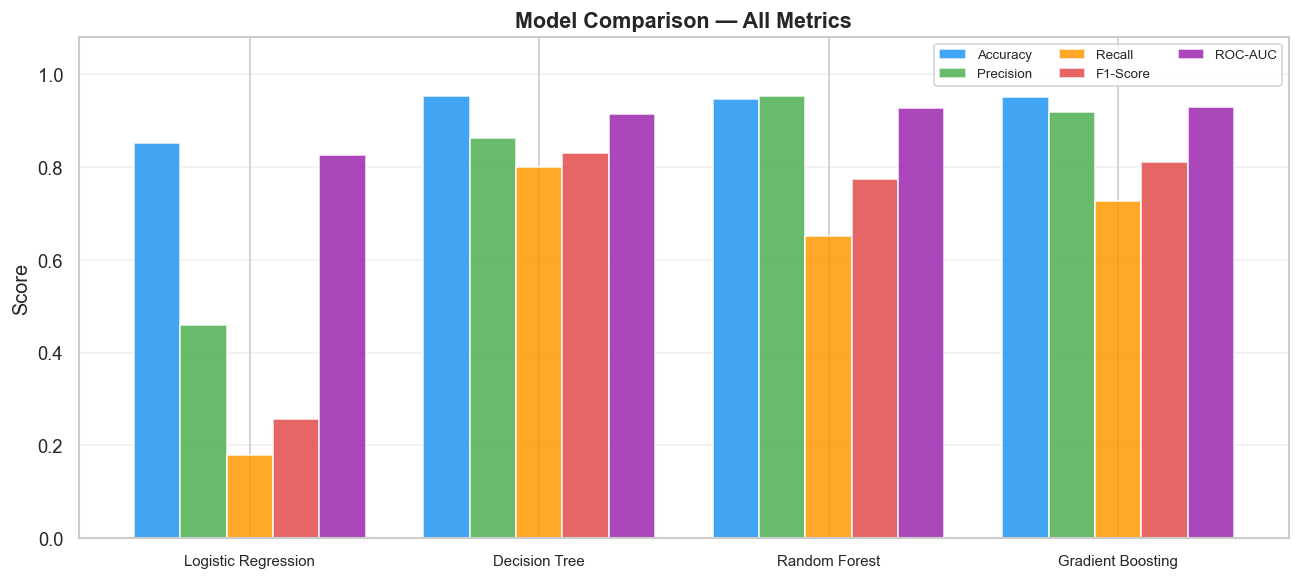

In [8]:
metrics = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(models)); width=0.16
colors = ["#2196F3","#4CAF50","#FF9800","#E24B4A","#9C27B0"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width, label=metric,
           color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + 2*width)
ax.set_xticklabels(results_df["Model"], fontsize=9)
ax.set_ylim(0, 1.08); ax.set_ylabel("Score")
ax.set_title("Model Comparison — All Metrics", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper right", ncol=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/level3/classification_plots/02_model_comparison.png")
plt.show()

## Step 5 — Hyperparameter Tuning (GridSearchCV on Random Forest)

In [9]:
param_grid = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features":      ["sqrt", "log2"],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=cv, scoring="f1", n_jobs=-1, verbose=0
)
grid_search.fit(X_train_sc, y_train)
best_model = grid_search.best_estimator_

print(f"Best params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_:.4f}")

Best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1  : 0.8154


In [10]:
y_pred_best = best_model.predict(X_test_sc)
y_prob_best = best_model.predict_proba(X_test_sc)[:,1]

print("Tuned Random Forest — Test Set Results:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_best):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=["No Churn","Churn"]))

Tuned Random Forest — Test Set Results:
  Accuracy  : 0.9505
  Precision : 0.9559
  Recall    : 0.6842
  F1-Score  : 0.7975
  ROC-AUC   : 0.9254

              precision    recall  f1-score   support

    No Churn       0.95      0.99      0.97       572
       Churn       0.96      0.68      0.80        95

    accuracy                           0.95       667
   macro avg       0.95      0.84      0.88       667
weighted avg       0.95      0.95      0.95       667



## Step 6 — Diagnostic Plots (Best Model)

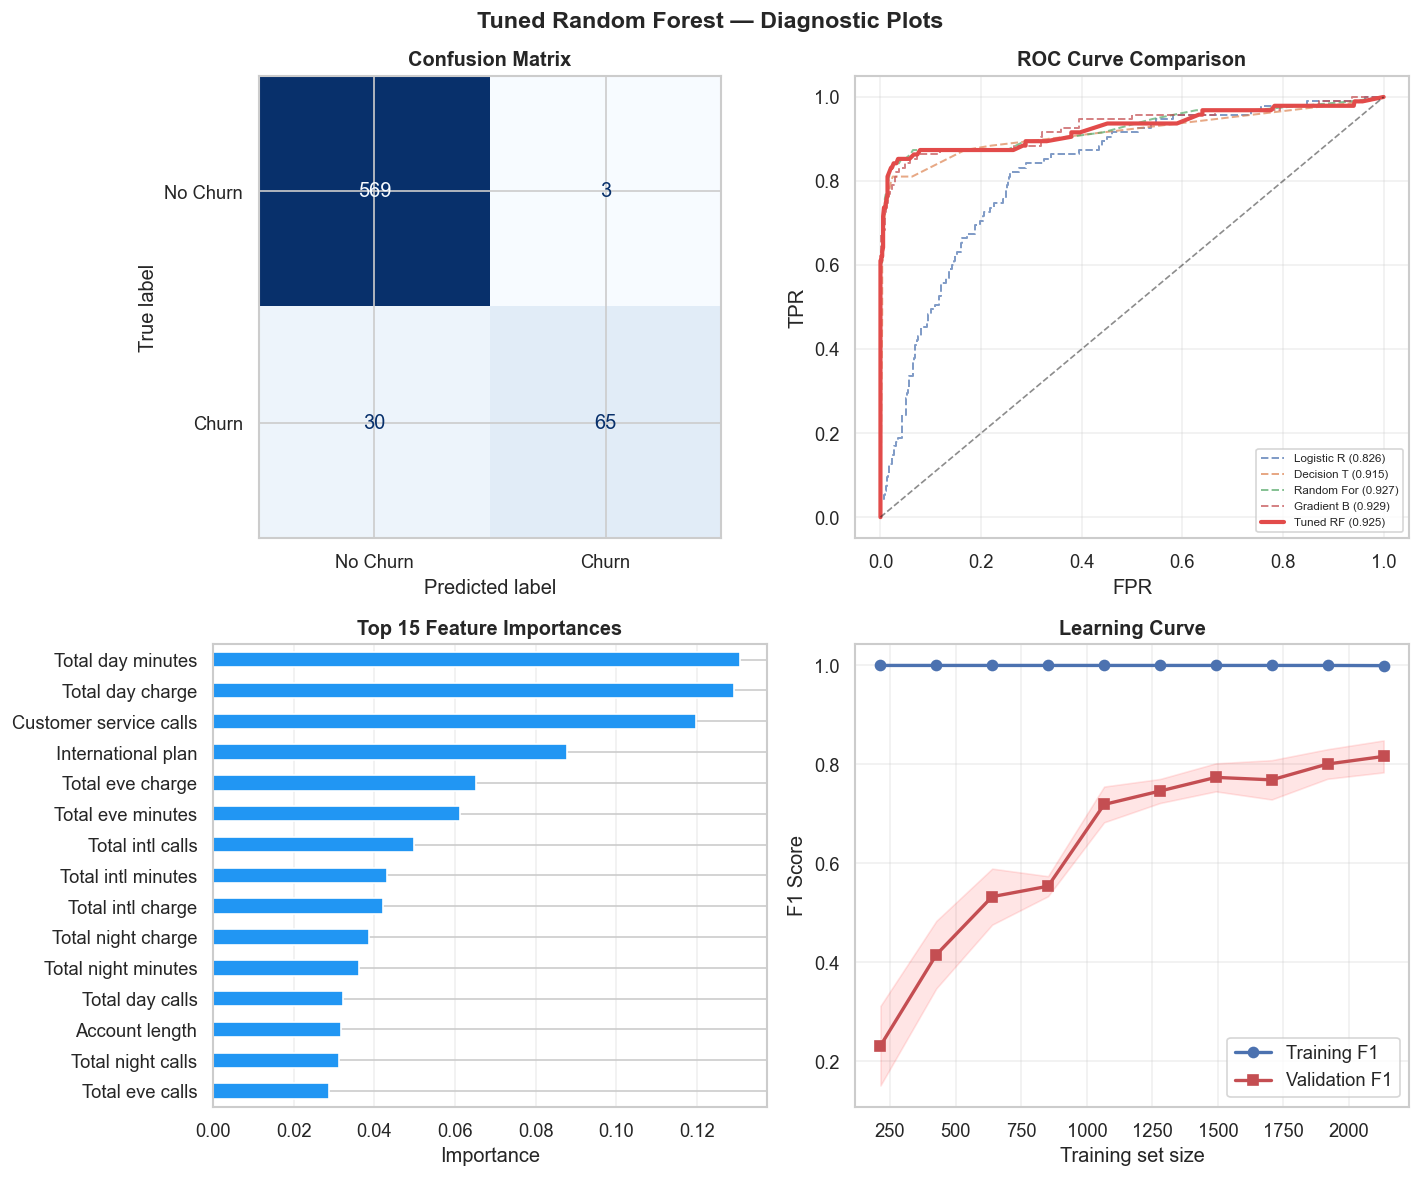

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Tuned Random Forest — Diagnostic Plots", fontsize=14, fontweight="bold")

# Confusion Matrix
ax = axes[0,0]
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best),
                       display_labels=["No Churn","Churn"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix", fontweight="bold")

# ROC Curve
ax = axes[0,1]
for res in results:
    fpr_m, tpr_m, _ = roc_curve(y_test, res["_prob"])
    ax.plot(fpr_m, tpr_m, lw=1.2, alpha=0.7, ls="--",
            label=f"{res['Model'][:10]} ({res['ROC-AUC']:.3f})")
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
ax.plot(fpr, tpr, color="#E24B4A", lw=2.5, label=f"Tuned RF ({roc_auc_score(y_test,y_prob_best):.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curve Comparison", fontweight="bold"); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Feature Importance
ax = axes[1,0]
feat_imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
feat_imp.nlargest(15).sort_values().plot(kind="barh", ax=ax,
                                          color="#2196F3", edgecolor="white")
ax.set_xlabel("Importance"); ax.set_title("Top 15 Feature Importances", fontweight="bold")
ax.grid(alpha=0.3, axis="x")

# Learning Curve
ax = axes[1,1]
train_sizes, tr_scores, val_scores = learning_curve(
    best_model, X_train_sc, y_train, cv=5, scoring="f1",
    train_sizes=np.linspace(0.1,1.0,10), n_jobs=-1)
ax.plot(train_sizes, tr_scores.mean(axis=1), "bo-", lw=2, label="Training F1")
ax.fill_between(train_sizes, tr_scores.mean(axis=1)-tr_scores.std(axis=1),
                tr_scores.mean(axis=1)+tr_scores.std(axis=1), alpha=0.1, color="blue")
ax.plot(train_sizes, val_scores.mean(axis=1), "rs-", lw=2, label="Validation F1")
ax.fill_between(train_sizes, val_scores.mean(axis=1)-val_scores.std(axis=1),
                val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.1, color="red")
ax.set_xlabel("Training set size"); ax.set_ylabel("F1 Score")
ax.set_title("Learning Curve", fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/level3/classification_plots/03_rf_diagnostics.png")
plt.show()